Machine learning is mainly divided into two types. 
1. supervised learning
2. unsupervised learning.
   
* If the data has specific 0utput(y), I will go with supervised learning.
* And if the data has no specific output, I will go with unsupervised learning.
* Under supervised learning, we have two problem types. One is regression and another one is classification.
* If the output is continuous, I will go with regression problem statements. If the output is discrete, I will go with classification problems.
* Linear regression comes under regression problem statement and logistic regression comes under classification problem statement.
* In unsupervised learning, clustering problems will be there. 

### Parametric and non parametric models:

* Before choosing algorithm, we have two models.
* One is parametric models and another one is non-parametric model.
  
  **1.parametric models:** The algorithm that comes up with some assumption and it will have some deliverables. Under parametric models, we have two problem types. One is linear regression and another one is logistic regression.

  **From the training data, we will get coefficient and intercept as deliverables for parametric models.**
  
  **2.Non-parametric model:** it does not come up with any assumption. So, no need to do any testings. Decision tree, random forest, SVM, KNN, gradient boosting are the examples.

### LINEAR REGRESSION: [REGRESSION PROBLEM]

* Linear regression is a supervised learning algorithm used to predict continuous numerical values.
  
* It learns the relationship between an input (X) and output variables (y) by fitting the best fit line and predict values of new data.

* **Linear regrrsssion line or best fitted line or regression line**

1. SIMPLE LINEAR REGRESSION:

* If we are predicting output based on one input feature .
* salary based on experience

$$y=MX+C$$

2.  MULTIPLE LINEAR REGRESSION:

* If we are predicting output based on more than one input feature, that is multiple linear regression.
* Salary based on experience, age, skills.

$$y = M_1X_1 + M_2X_2 + M_3X_3 + C$$

### why best-fitted line ?

* Most of the times real data is messy.
* So, line cannot pass through every point.
* Machine tries to draw one line that is closest to all the points.
* * **Linear regrrsssion line or best fitted line or regression line**

**NOTE:** Refer handwritten notes for slope, intercept , training data,testing time and assumptions

### How does Machine Learning work ?  or Life cycle of data scientist or How do you o and solve a machine learning problem statement ? or Explain the Data Science (or Machine Learning) project life cycle. or steps of project

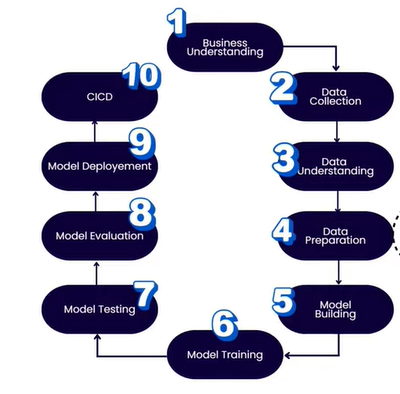

## 1.Business understanding: 

- The business problem is to predict the mileage (MPG) of a car using features such as horsepower, engine volume, speed, and weight.
-  Accurate mileage prediction helps the company design fuel-efficient vehicles, reduce testing costs, and estimate performance before manufacturing.

### 1.1 Business Objective

Develop a Machine Learning model that predicts the Mileage (MPG) of a car using its characteristics.

### output / Target Variable (Dependent Variable)

MPG (Miles Per Gallon)

This is the value we want to predict.

Since MPG is a continuous numerical value, this is a Regression Problem.

### Input Variables (Independent Variables)
HP (Horsepower)
VOL (Engine Volume)
SP (Top Speed)
WT (Weight)

These features help predict the mileage.

**Here we have input and specific output so it is supervised ML**

**Here output is continuous [Number] , so this is Regression problem.**

### Business Questions

The company wants answers to questions such as:

1. How does horsepower affect mileage?
2. Does heavier vehicle weight reduce mileage?
3. Does engine volume influence fuel efficiency?
4. Which factor has the greatest impact on mileage?
5. Can we accurately predict mileage for a new car before manufacturing?

## 2.Data collection

### 2.1 Import necessary libraries:


In [27]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

## 2.2.Import Dataset:


In [2]:
cars_data = pd.read_csv(filepath_or_buffer = "Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3.Data Understanding:

### 3.1 Perform initial Analysis:

In [3]:
cars_data.shape   #ROWS --> observations / records ; COLUMNS --> Parameters or features

(81, 5)

In [4]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [5]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [6]:
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [7]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


### Now Lets check the assumptions:


### Test 1 : Linearity Test

use lmplot for Linearity Test -- Plot data and regression model fits across a FacetGrid.

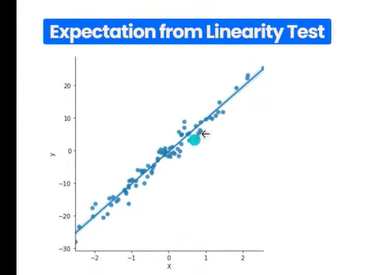


Most of the data points shhould lie near to the reg line

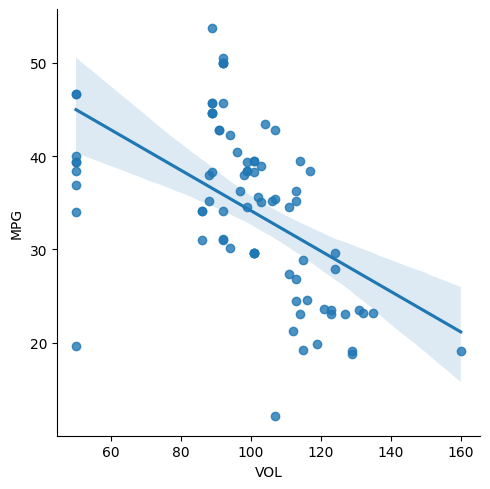

In [8]:
sns.lmplot(data = cars_data , x = 'VOL', y = 'MPG')
plt.show()

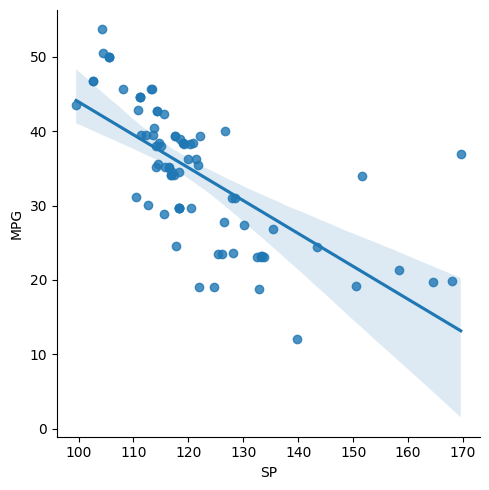

In [9]:
sns.lmplot(data = cars_data , x = 'SP', y = 'MPG')
plt.show()

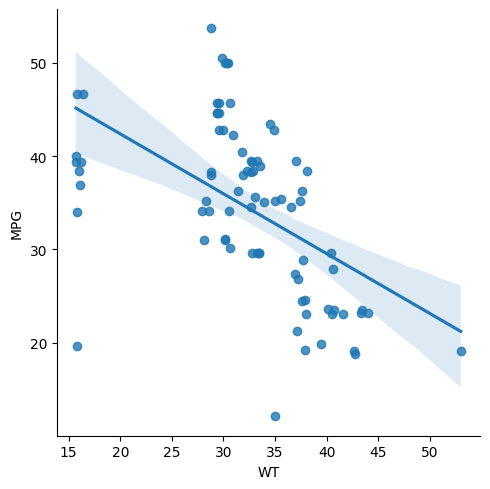

In [10]:
sns.lmplot(data = cars_data , x = 'WT', y = 'MPG')
plt.show()

### Test 1 Result :Linearity failed 

### Test 2 Normality Test

- All the input variables are in normally distributed.
- use histplot or distplot

  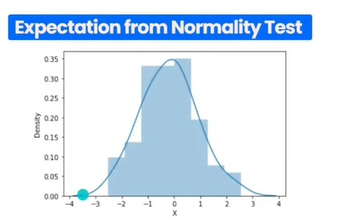

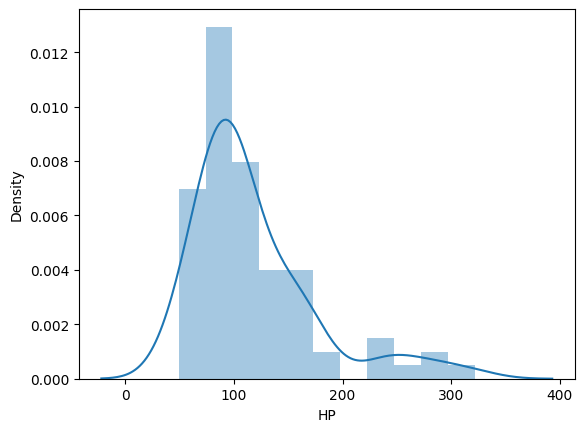

In [11]:
sns.distplot(cars_data['HP'])
plt.show()

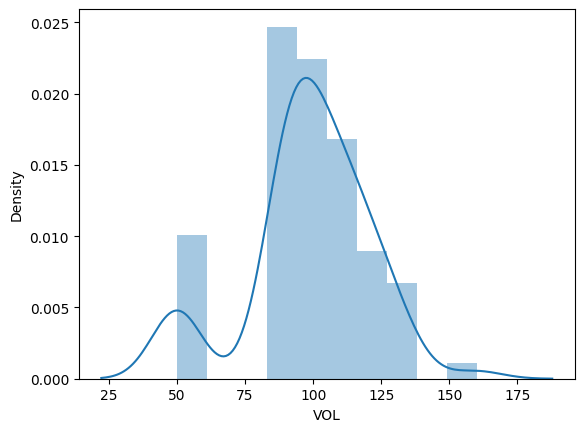

In [12]:
sns.distplot(cars_data['VOL'])
plt.show()

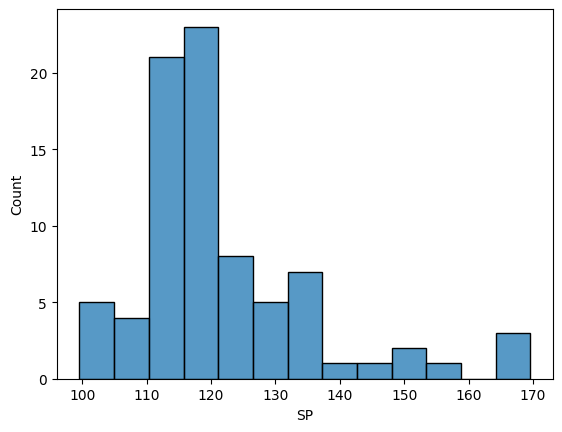

In [13]:
sns.histplot(cars_data['SP'])
plt.show()

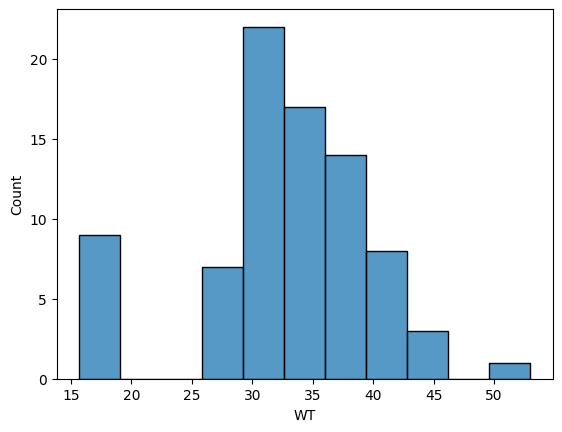

In [14]:
sns.histplot(cars_data['WT'])
plt.show()

### Test 2 Normality also failed

### Test 3 - Multicollinearity test

| Correlation Coefficient (r) | Interpretation                   |
| --------------------------: | -------------------------------- |
|              +0.90 to +1.00 | Very Strong Positive Correlation |
|              +0.70 to +0.89 | Strong Positive Correlation      |
|              +0.40 to +0.69 | Moderate Positive Correlation    |
|              +0.10 to +0.39 | Weak Positive Correlation        |
|                           0 | No Correlation                   |
|              -0.10 to -0.39 | Weak Negative Correlation        |
|              -0.40 to -0.69 | Moderate Negative Correlation    |
|              -0.70 to -0.89 | Strong Negative Correlation      |
|              -0.90 to -1.00 | Very Strong Negative Correlation |


In [15]:
correlation_matrix=cars_data.corr()
correlation_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

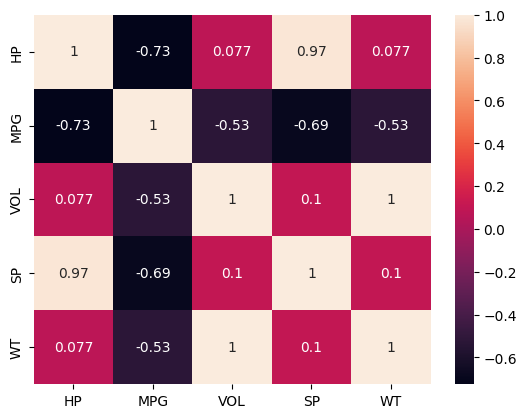

In [16]:
sns.heatmap(data = correlation_matrix,annot=True)

* compare input features
* each input should be new
* There is no multicollinearity between input feature [ HP VS VOL , SP,WT  ; SIMILARLY FOR VOL , SP,WT]
* Independent variables should not be highly correlated with each other.

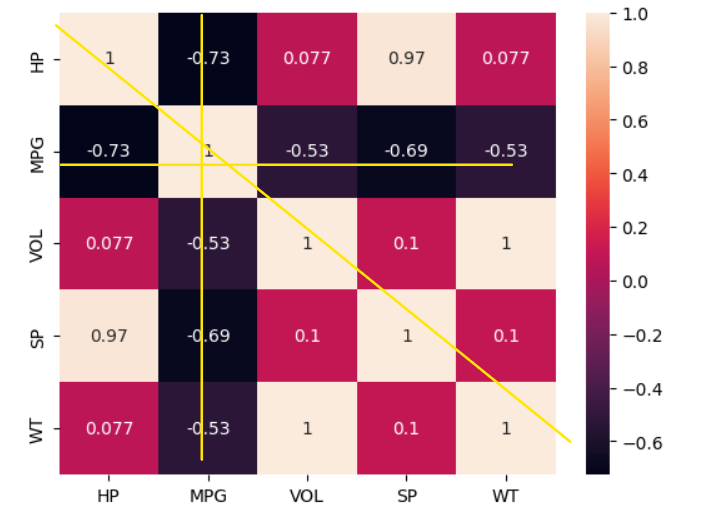

### Test 3 result there is multicoLlinearity in the data

### Test 4 Autoregression passed  -- bcoz there is no time based input clumns in the data 

### Homoscadacity , Residual error -- can be done after Model is built,trained and tested

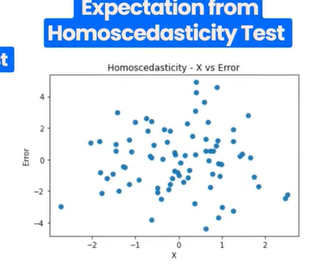   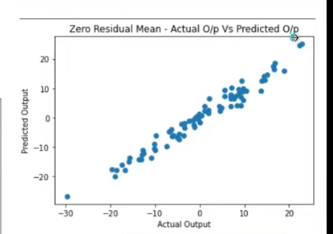


## 4.Data preparation

In [17]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


* There is nothing to prepare because all features are numeric.

* Feature engg techniques are applied in data prep

Scikit-learn (commonly abbreviated as sklearn) is a premier open-source Python library used for building, training, and evaluating classical machine learning models.

### SPLITTING INPUTS AND OUTPUTS

In [18]:
X = cars_data[["HP","VOL","SP","WT"]]
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [19]:
y =cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

## 5.Model Building

#### Train Test split

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y , shuffle=True,random_state=42 , test_size=0.20)
X_train,X_test,y_train,y_test

(     HP  VOL          SP         WT
 61  120  116  117.668550  37.860411
 55  130  124  126.404312  40.589068
 40   95  113  116.392639  37.392524
 9    80   94  115.645204  30.920154
 64  150  121  128.128401  40.159482
 ..  ...  ...         ...        ...
 20   92   99  119.105055  32.324650
 60  145  111  130.208698  36.888153
 71  162  135  133.415985  44.013139
 14   66   89  108.185353  29.347279
 51  115  101  118.288996  33.436711
 
 [64 rows x 4 columns],
      HP  VOL          SP         WT
 30   84  114  113.484609  37.042350
 0    49   89  104.185353  28.762059
 22   95  101  120.288996  32.675828
 31   84  101  112.288996  33.234361
 18   78   91  114.369293  29.929394
 28   52  104   99.564907  34.483207
 10   73   89  111.185353  29.363341
 70  280   50  164.598513  15.823060
 4    53   92  104.461264  29.889149
 12   92   99  122.105055  32.813592
 49  115  101  118.288996  33.458472
 33  102  113  121.392639  37.573290
 67  165  127  133.680223  41.573975
 35   90   9

In [33]:
linear_model = LinearRegression()
linear_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 6.Model Training

#### 6.1 Training data

In [38]:
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##### Delivaerables:

In [44]:
linear_model.coef_  # slope value for all 4 inputs

array([-0.2148991 ,  1.24947152,  0.17749398, -4.32563228])

In [46]:
linear_model.intercept_

np.float64(55.47027970121134)

### 7.Model Testing:

In [48]:
y_train_pred =linear_model.predict(X_train)
y_train_pred

array([3.17363254e+01, 2.93304848e+01, 3.51578290e+01, 4.25057852e+01,
       2.34483373e+01, 4.37169186e+01, 3.70965468e+01, 4.25579161e+01,
       2.37444938e+01, 3.73001950e+01, 2.51592833e+01, 4.49489804e+01,
       3.50175840e+01, 3.89903689e+01, 1.20935919e+01, 5.42791562e+01,
       3.42777400e+01, 2.06967620e+01, 4.08710549e+01, 2.16795781e+01,
       4.91168095e+01, 4.01466946e+01, 4.36400292e+01, 1.06985122e+01,
       4.30141532e+01, 4.89963519e+01, 3.79108188e+01, 5.20656201e+01,
       3.69879301e+01, 4.62176110e+01, 4.19545122e+01, 2.16887597e+01,
       3.89940803e+01, 3.57734433e+01, 4.14569668e-02, 4.26620458e+01,
       3.85052373e+01, 3.65288886e+01, 3.86762183e+01, 3.62680249e+01,
       4.29133420e+01, 4.26536304e+01, 2.01196150e+01, 3.63516029e+01,
       5.09021686e+01, 4.02960674e+01, 9.06386219e+00, 3.52679995e+01,
       2.51595959e+01, 1.01967456e+01, 4.11575820e+01, 3.48816782e+01,
       4.55326324e+01, 3.23147918e+01, 4.19346913e+01, 4.67145526e+01,
      

In [49]:
y_test_pred =linear_model.predict(X_test)
y_test_pred

array([39.76975856, 50.22137173, 41.25844633, 39.78637314, 43.24636797,
       42.75106072, 43.70532409, 18.54261186, 48.2837866 , 39.13062077,
       33.22004694, 33.75908134, 22.58851865, 40.95548192, 22.29189019,
       37.35308017, 18.18726484])

### 8.Model Evaluation

**What is Error?**

Error means:

Difference between Actual Value and Predicted Value.

In [25]:
error = y - y_pred
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

#### Evaluation Metrics:

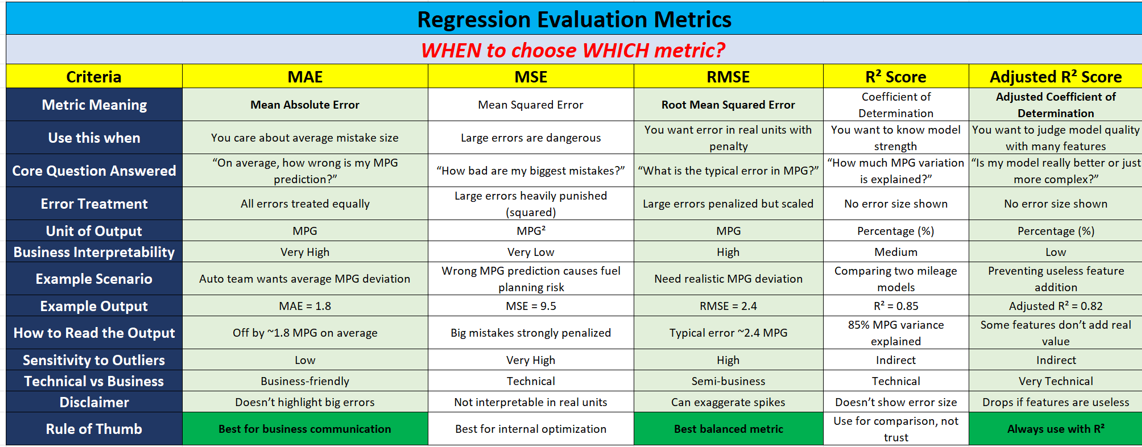

In [60]:
from sklearn.metrics import mean_absolute_error ,mean_squared_error,root_mean_squared_error,r2_score

#### 8.1 Training data 

#### 1.MAE (Mean Absolute Error)

In [51]:
mean_absolute_error(y_train,y_train_pred)

4.3839625650062075

#### 2.MSE (Mean squared Error)

In [55]:
mean_squared_error(y_train,y_train_pred)

42.26270830904136

#### 3.Root mean squared error:

In [58]:
root_mean_squared_error(y_train,y_train_pred)

6.500977488735164

#### 4. r2 score

In [76]:
r2_score(y_train,y_train_pred)

0.451632880572135

#### To see Adjusted R2 score we are using OLS technique from statsmodel

In [67]:
import statsmodels.formula.api as smf

In [77]:
linear_stats_model = smf.ols(formula ="MPG ~ HP+VOL+WT+SP", data = cars_data).fit()
linear_stats_model

#### r2 score

In [78]:
print(linear_stats_model.rsquared )

0.7705372737359844


#### adjusted r2 score

In [79]:
print(linear_stats_model.rsquared_adj)

0.7584602881431415


#### 8.2 Testing data 

#### 1.MAE (Mean Absolute Error)

In [53]:
mean_absolute_error(y_test,y_test_pred)

1.5854578489192659

#### 2.MSE (Mean squared Error)

In [56]:
mean_squared_error(y_test,y_test_pred)

3.9238272824172724

#### 3.Root mean squared error:

In [59]:
root_mean_squared_error(y_test,y_test_pred)

1.9808652862870995

#### 4. r2 score

In [62]:
r2_score(y_test,y_test_pred)

0.9600980940013194

**Residual error is the difference between the actual value and the predicted value in a regression model.**

### Test 5: Lets now perform Homoscedasticity test 

* The residuals[error] should have similar variance accross all data points
* Homoscedasticity is a statistical term describing data where the variance of the error terms (residuals) remains constant across all levels of the independent variables.

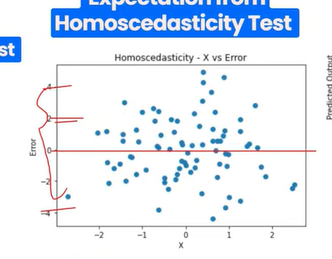

In [ ]:
sns.scatterplot(data=cars_data,x='HP',y=error)
plt.show()

NOTE: HP and SP conveys same meaning , VOL and WT conveys same meaning . so take any one col on it

In [ ]:
sns.scatterplot(data=cars_data,x='VOL',y=error)
plt.show()

### Test 5 Homoscedasticity test Failed

### Test 6: Zero residual mean

* Actual output and predicted output should be linear

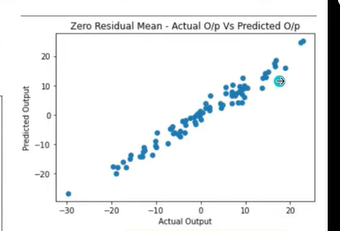

In [ ]:
sns.scatterplot(x=cars_data['MPG'],y=y_pred)

### Test 6: Zero residual mean failed

### 9.Model Deployment

In [ ]:
from pickle import dump

In [ ]:
dump(obj = linear_model, file = open(file = 'linear_intelligence_pickle',mode ='wb'))

HOW TO LOAD THIS PICKLE FILE IN BACKEND ?

In [ ]:
from pickle import load

In [ ]:
linear_intelligence_pickle_load = load(file = open(file = 'linear_intelligence_pickle',mode ='rb'))
linear_intelligence_pickle_load

In [ ]:
linear_intelligence_pickle_load.predict(X)

In [68]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099
